### 텍스트 전처리

- 뉴스원본
- 제주관광공사

In [2]:
import pandas as pd

df = pd.read_csv("../data/11-1_뉴스원본.csv")
df.head(3)


,제목,본문,카테고리,요약,출처URL
0,현대백화점그룹 더현대 광주 추진,서울 연합뉴스 현대백화점그룹이 광주광역시에 서울 여의도 더현대 서울 과 같은 문화복...,경제,"6 6일 현대백화점그룹이 광주시에 문화복합몰을 만든다고 6일 밝혔으며, 광주시는 서...",https://n.news.naver.com/mnews/article/001/001...
1,이스타항공 이상직 회사와 무관…오해 살 언동 말아야,전주 뉴시스 김얼 기자 이스타항공 자금 배임·횡령으로 전주교도소에 수감됐었던 이상직...,경제,이이스항공은 자금 배임·횡령으로 전주교도소에 수감됐었던 이상직 전 의원이 출소한 것...,https://n.news.naver.com/mnews/article/003/001...
2,농협은행 농협금융 출범 10주년 기념주화 NFT 이벤트,NH농협은행은 올해 농협금융 출범 10주년을 맞아 이달 29일까지 ‘10주년 기념주...,경제,NH농협은행은 올해 농협금융 출범 10주년을 맞아 이달 29일까지 소셜미디어 인스타...,https://n.news.naver.com/mnews/article/366/000...


In [4]:
df[['제목','본문']].head(3)

,제목,본문
0,현대백화점그룹 더현대 광주 추진,서울 연합뉴스 현대백화점그룹이 광주광역시에 서울 여의도 더현대 서울 과 같은 문화복...
1,이스타항공 이상직 회사와 무관…오해 살 언동 말아야,전주 뉴시스 김얼 기자 이스타항공 자금 배임·횡령으로 전주교도소에 수감됐었던 이상직...
2,농협은행 농협금융 출범 10주년 기념주화 NFT 이벤트,NH농협은행은 올해 농협금융 출범 10주년을 맞아 이달 29일까지 ‘10주년 기념주...


### 정규표현식
- re.sub(찾을부분, 바꿀것, 텍스트)

In [7]:
import re

sample = "행사 안내입니다. https://events.com/2026 참고하세요"

# print(sample)
# 링크를 제거 해보자
result = re.sub(r"http\S+","",sample)
result


'행사 안내입니다.  참고하세요'

In [10]:
sample = "문의는 yth@news.com 입니다."

result = re.sub(r"\S+@\S+","",sample)
result

'문의는  입니다.'

In [11]:
sample = "정제후 삼성전자 주가 200    상승"

result = re.sub(r" +"," ",sample)
result

'정제후 삼성전자 주가 200 상승'

In [12]:
sample = "정제후 삼성전자 주가 200    상승"

result = re.sub(r"[0-9]*"," ",sample)
result

' 정 제 후   삼 성 전 자   주 가            상 승 '

### 3. 정규화
- 정제 -> 불필요한 것을 지우기
- 정규화 -> 같은 의미인데 다르게 적힌 표기를 하나로 통일
- 예) 
    - Apple, apple -> 같은 단어
    - 대소문자 통일, 공백, 반복문자 정리
    - 유니코드 정규화
    

### 4. 경우들을 묶어서 한꺼번에 처리하는 함수 만들기

- 정제함수 만들기
    1. URL 제거하기
    2. 이메일 제거
    3. 특수문자 제거
    4. 공백처리

In [13]:
def clean_news_text(text):
      """뉴스 문장에서 불필요한 내용을 정리하는 함수"""

      # 1. URL 제거: https://..., http://..., www....
      text = re.sub(r"https?://\S+|www\.\S+", "", text)

      # 2. 이메일 제거: example@email.com 형태
      text = re.sub(r"\S+@\S+", "", text)

      # 3. 특수문자 제거
      # 한글, 영문, 숫자, 공백만 남깁니다.
      text = re.sub(r"[^가-힣a-zA-Z0-9\s]", " ", text)

      # 4. 공백 처리
      # 여러 칸의 공백, 줄바꿈, 탭을 한 칸으로 바꾸고 앞뒤 공백을 제거합니다.
      text = re.sub(r"\s+", " ", text).strip()

      return text


  # 정제할 뉴스 문장
news = """
[속보] 서울 날씨가 맑습니다!!! 자세한 내용: https://news.example.com/weather
문의: reporter@example.com
오늘 기온은 25도입니다.   시민들은 "나들이"를 즐겼습니다.
"""

cleaned_news = clean_news_text(news)

print("정제 전:")
print(news)

print("\n정제 후:")
print(cleaned_news)

정제 전:

[속보] 서울 날씨가 맑습니다!!! 자세한 내용: https://news.example.com/weather
문의: reporter@example.com
오늘 기온은 25도입니다.   시민들은 "나들이"를 즐겼습니다.


정제 후:
속보 서울 날씨가 맑습니다 자세한 내용 문의 오늘 기온은 25도입니다 시민들은 나들이 를 즐겼습니다


In [14]:
def clean_news_title(text):
      # 1. URL 제거
      text = re.sub(r"https?://\S+", " ", text)

      # 2. 이메일 제거
      text = re.sub(r"\S+@\S+", " ", text)

      # 3. 특수문자 제거
      # 한글, 영어, 숫자, 공백만 남깁니다.
      text = re.sub(r"[^가-힣a-zA-Z0-9\s]", " ", text)

      # 4. 여러 공백을 한 칸으로 바꾸고, 앞뒤 공백 제거
      text = re.sub(r"\s+", " ", text).strip()

      return text

In [16]:
df.head(1)
df['본문'][3]

'img tag s 지난 30일 서울의 한 주유소. 〈사진 연합뉴스〉 img tag e 오늘 1일 부터 유류세율 인하 폭이 확대됩니다. 올해 3분기에는 생애최초 주택 구매 대출 규제도 완화됩니다. 기획재정부에 따르면 정부는 계속되는 고유가 상황에 따라 국민의 유류비 부담 완화를 위해 이날부터 유류세를 법정 최대한도인 37%로 인하합니다. img tag s 〈사진 기획재정부〉 img tag e 기존 30%에서 대통령령으로 가능한 최대폭까지 확대한 겁니다. 이에 따라 휘발유는 리터당 57원 경유는 38원 LPG는 12원 싸집니다. img tag s 〈사진 기획재정부〉 img tag e 또 오는 10월부터는 코로나19 피해로 대출상환에 어려움을 겪는 소상공인과 자영업자를 위한 채무조정 프로그램도 시행합니다. 최대 30조원 규모로 소상공인·자영업자 새출발기금 가칭 을 설립해 대출채권 매입 등의 방식으로 상환일정 조정과 채무감면을 지원할 계획입니다. img tag s 〈사진 기획재정부〉 img tag e 부동산 대출 규제도 완화합니다. 생애 최초 주택 구매자에 대해서는 LTV 상한을 주택 소재 지역이나 가격 소득과 상관없이 80%로 완화합니다. 올해 3분기 중에 시행할 계획입니다. 지금은 투기과열지구 경우 LTV가 60%까지 조정대상지역은 70%까지 적용되고 있습니다. 이외에 올해 하반기에 바뀌는 정책은 기획재정부 홈페이지와 지자체 공공기관 등에서 확인할 수 있습니다.'

In [17]:
result = clean_news_title(df['본문'][3])
print(result)

img tag s 지난 30일 서울의 한 주유소 사진 연합뉴스 img tag e 오늘 1일 부터 유류세율 인하 폭이 확대됩니다 올해 3분기에는 생애최초 주택 구매 대출 규제도 완화됩니다 기획재정부에 따르면 정부는 계속되는 고유가 상황에 따라 국민의 유류비 부담 완화를 위해 이날부터 유류세를 법정 최대한도인 37 로 인하합니다 img tag s 사진 기획재정부 img tag e 기존 30 에서 대통령령으로 가능한 최대폭까지 확대한 겁니다 이에 따라 휘발유는 리터당 57원 경유는 38원 LPG는 12원 싸집니다 img tag s 사진 기획재정부 img tag e 또 오는 10월부터는 코로나19 피해로 대출상환에 어려움을 겪는 소상공인과 자영업자를 위한 채무조정 프로그램도 시행합니다 최대 30조원 규모로 소상공인 자영업자 새출발기금 가칭 을 설립해 대출채권 매입 등의 방식으로 상환일정 조정과 채무감면을 지원할 계획입니다 img tag s 사진 기획재정부 img tag e 부동산 대출 규제도 완화합니다 생애 최초 주택 구매자에 대해서는 LTV 상한을 주택 소재 지역이나 가격 소득과 상관없이 80 로 완화합니다 올해 3분기 중에 시행할 계획입니다 지금은 투기과열지구 경우 LTV가 60 까지 조정대상지역은 70 까지 적용되고 있습니다 이외에 올해 하반기에 바뀌는 정책은 기획재정부 홈페이지와 지자체 공공기관 등에서 확인할 수 있습니다


In [18]:
df['정제본문'] = df['본문'].apply(clean_news_title)
df.head(3)

,제목,본문,카테고리,요약,출처URL,정제본문
0,현대백화점그룹 더현대 광주 추진,서울 연합뉴스 현대백화점그룹이 광주광역시에 서울 여의도 더현대 서울 과 같은 문화복...,경제,"6 6일 현대백화점그룹이 광주시에 문화복합몰을 만든다고 6일 밝혔으며, 광주시는 서...",https://n.news.naver.com/mnews/article/001/001...,서울 연합뉴스 현대백화점그룹이 광주광역시에 서울 여의도 더현대 서울 과 같은 문화복...
1,이스타항공 이상직 회사와 무관…오해 살 언동 말아야,전주 뉴시스 김얼 기자 이스타항공 자금 배임·횡령으로 전주교도소에 수감됐었던 이상직...,경제,이이스항공은 자금 배임·횡령으로 전주교도소에 수감됐었던 이상직 전 의원이 출소한 것...,https://n.news.naver.com/mnews/article/003/001...,전주 뉴시스 김얼 기자 이스타항공 자금 배임 횡령으로 전주교도소에 수감됐었던 이상직...
2,농협은행 농협금융 출범 10주년 기념주화 NFT 이벤트,NH농협은행은 올해 농협금융 출범 10주년을 맞아 이달 29일까지 ‘10주년 기념주...,경제,NH농협은행은 올해 농협금융 출범 10주년을 맞아 이달 29일까지 소셜미디어 인스타...,https://n.news.naver.com/mnews/article/366/000...,NH농협은행은 올해 농협금융 출범 10주년을 맞아 이달 29일까지 10주년 기념주화...


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.rcParams["font.family"] = "Malgun Gothic"   # 한글 깨짐 방지(윈도우 기본 폰트)
plt.rcParams["axes.unicode_minus"] = False


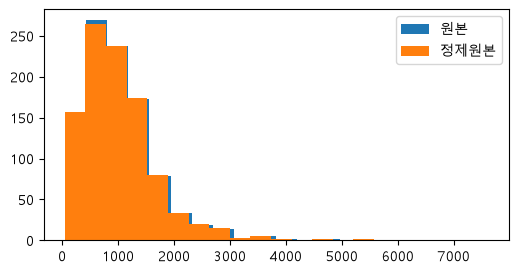

In [20]:
plt.figure(figsize=(6,3))
plt.hist(df['본문'].str.len(), bins=20, label="원본")
plt.hist(df['정제본문'].str.len(), bins=20, label="정제원본")
plt.legend()
plt.show()

### 5. 실전 비짓 제주 데이터로 해보기
- 관광 리뷰 데이터

In [26]:
jeju = pd.read_csv("../data/11-1_visitjeju_reviews.csv", encoding="cp949")

jeju.to_csv(
    "../data/11-1_visitjeju_reviews.csv",
    encoding="utf-8",
    index=False
)

In [28]:
jeju = pd.read_csv("../data/11-1_visitjeju_reviews.csv", encoding="utf-8")
jeju.head()

,리뷰내용,추천수
0,제주특별자치도 서귀포시 안덕면 병악로 166 에 위치한 카멜리아힐동백언덕.친구들과함...,159
1,"성이시돌목장에 가면 테쉬폰, 우유부단 뿐만 아니라 왕따나무도 이색볼거리로 손꼽히고 ...",132
2,메밀꽃 지평선과 하늘입니다,57
3,#제주소녀 #엄샤 #제주도민 #도민추천 #인생샷 #명소 #인생샷명소 #해바라기 #꽃밭,29
4,#제주소녀 #엄샤 #도민추천 #먹이주기체험 #양떼목장 #애월읍 #체험학습 #육아,29


In [46]:
import re
import pandas

def clean_review(text):
    if pandas.isna(text):
        return ""

    stop_words = [
        "제주소녀",
        "엄사",
        "제주도민",
        "도민추천",
        "인생샷",
        "명소",
        "휴일나들이",
        "엄샤",
        "ㅠ"
    ]

    # 특수문자, # 제거
    text = re.sub(r"[^가-힣A-Za-z\s]", " ", text)

    # 반복되는 불필요한 단어 제거
    words = text.split()
    words = [word for word in words if word not in stop_words]

    return " ".join(words)


jeju["리뷰정제내용"] = jeju["리뷰내용"].apply(clean_review)
jeju = jeju.dropna(subset=["리뷰내용"])


In [47]:
from pathlib import Path
import webbrowser

file_path = Path("jeju_review_compare.html").resolve()

html = jeju[["리뷰내용", "리뷰정제내용"]].to_html(index=False)

html = f"""
<html>
<head>
<meta charset="utf-8">
<style>
    table {{
        border-collapse: collapse;
        width: 100%;
    }}

    th, td {{
        border: 1px solid #ccc;
        padding: 8px;
        vertical-align: top;
        word-break: break-all;
    }}

    th {{
        background: #eee;
        position: sticky;
        top: 0;
    }}

    td {{
        max-width: 600px;
    }}
</style>
</head>

<body>
{html}
</body>
</html>
"""

file_path.write_text(html, encoding="utf-8")

webbrowser.open(file_path.as_uri())

True